<a href="https://colab.research.google.com/github/val-ium/data-analytics/blob/main/music_money.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Top Royalties of 2023

## Importing Streaming Data

### Loading the Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
"""
This data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without the Kaggle API.

The CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.

"""

"\nThis data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without the Kaggle API.\n\nThe CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.\n\n"

In [3]:
URL = "https://github.com/val-ium/data-analytics/raw/refs/heads/main/spotify-2023.csv"

df = pd.read_csv(URL, encoding = "latin-1")

In [ ]:
#Here we see the data is relatively clean. The only null values are in two columns we wont use for this analysis.
df.isnull().sum()

In [11]:
#Where there are no null values in "streams", here im checking to make sure there are no 0 values for streams.
df["streams"].min()

'100409613'

In [ ]:
desired_columns =[]
df = df[desired_columns]

### .apply to creating a new column: "splits"

In [ ]:
"""
I want to calculate royalties, I need to know how many artists are in each song.

More artists = more splits.

I'm going to create a new column called "splits" to describe this.

"""

'\nI want to calculate royalties, I need to know how many artists are in each song.\n\nMore artists = more splits.\n\nI\'m going to create a new column called "splits" to describe this.\n\n'

In [ ]:
#Thankfully, the raw data separates each artist by a comma.

def count_artists(artist_string):
  if "," in artist_string:
    return len(artist_string.split(","))
  else:
    return 1


In [ ]:
#Now I want to create a column describing how many artists are on each song.

df["splits"] = df["artist(s)_name"].apply(count_artists)

###Vizualizing "splits"


<Axes: ylabel='Songs with X contributors.'>

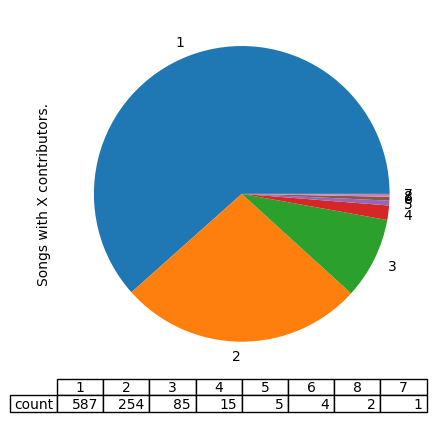

In [ ]:
#This pie chart shows that most songs are solo performances and a minority of songs have multiple artists.

collaboration_distribution = df["splits"].value_counts()

collaboration_distribution.plot(kind = "pie", ylabel= "Songs with X contributors.",table= True)

### How many streams does each artist have in this data?

##Counting Streams

### Not all streams are created equal.

In [ ]:
"""
Streams on a solo song are worth more than streams from a collaboration.
This function stores all the songs for an artist in a df then counts streams by collaboration size.
"""

In [ ]:
def split_streams(artist_name):



  all_songs = df[df["artist(s)_name"].str.contains(artist_name, case = False)]

  streams_by_split = all_songs.groupby("splits")["streams"].sum()

  return streams_by_split



## How much money does each artist recieve?


In [ ]:
#More artists on a track means less money for each artist.


##Who Made the Most Money?